# 16. Interpretabilidad y análisis de errores de los modelos finales

## 16.1. Objetivo

En el notebook anterior se seleccionaron, optimizaron y evaluaron los modelos finales para la clasificación de los códigos de calidad de las componentes de irradiancia GHI, DNI y DHI.

Una vez validado su rendimiento predictivo, este notebook se centra en analizar el comportamiento interno de los modelos y comprender las condiciones en las que se producen sus errores.

Los objetivos de este análisis son:

- identificar las variables con mayor influencia en las predicciones mediante **Permutation Importance**;
- analizar mediante **SHAP** cómo contribuyen las distintas variables a las decisiones de los modelos, tanto de forma global como para observaciones individuales;
- comparar los patrones de interpretabilidad obtenidos para GHI, DNI y DHI;
- estudiar en qué condiciones solares, temporales y de calidad de los datos se concentran los errores de clasificación.

Este análisis complementa las métricas obtenidas previamente y permite evaluar no solo cuánto aciertan los modelos, sino también si sus decisiones presentan un comportamiento interpretable y coherente con el problema físico estudiado.

In [23]:
from pathlib import Path
import json
import joblib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf

from sklearn.metrics import f1_score

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## 16.2. Preparación del análisis

Se cargan el dataset procesado, los modelos finales y los metadatos generados durante la optimización. A partir de estos últimos se recuperan las variables utilizadas por cada modelo y el año reservado para su evaluación.

Las variables predictoras se preparan mediante las mismas funciones de preprocesamiento utilizadas durante el modelado, manteniendo así la coherencia entre entrenamiento, evaluación e interpretabilidad.

In [24]:
DATA_PATH = Path(
    "../data/processed/dataset_solar_2023_2024_v3.parquet"
)

MODELS_PATH = Path("../models/final")

df = pd.read_parquet(DATA_PATH)

with open(
    MODELS_PATH / "model_metadata.json",
    "r",
    encoding="utf-8",
) as f:
    model_metadata = json.load(f)

In [25]:
model_ghi = tf.keras.models.load_model(
    MODELS_PATH / "codigo_ghi_mlp.keras"
)

model_dni = joblib.load(
    MODELS_PATH / "codigo_dni_hgb.joblib"
)

model_dhi = joblib.load(
    MODELS_PATH / "codigo_dhi_hgb.joblib"
)

scaler_ghi = joblib.load(
    MODELS_PATH / "codigo_ghi_scaler.joblib"
)

In [26]:
TEST_YEAR = model_metadata["codigo_ghi"]["test_year"]

df_test = (
    df[df["ano"] == TEST_YEAR]
    .copy()
    .reset_index(drop=True)
)

In [27]:
from src.preprocessing.model_preprocessing import convert_model_dtypes
features_ghi = model_metadata["codigo_ghi"]["features"]
features_dni = model_metadata["codigo_dni"]["features"]
features_dhi = model_metadata["codigo_dhi"]["features"]

X_test_ghi = convert_model_dtypes(
    df_test[features_ghi]
)

X_test_dni = convert_model_dtypes(
    df_test[features_dni]
)

X_test_dhi = convert_model_dtypes(
    df_test[features_dhi]
)

y_test_ghi = df_test["codigo_ghi"].copy()
y_test_dni = df_test["codigo_dni"].copy()
y_test_dhi = df_test["codigo_dhi"].copy()

In [28]:
print(f"GHI: {X_test_ghi.shape}")
print(f"DNI: {X_test_dni.shape}")
print(f"DHI: {X_test_dhi.shape}")

GHI: (525600, 14)
DNI: (525600, 18)
DHI: (525600, 21)


## 16.3. Permutation Importance

Una vez evaluado el rendimiento predictivo de los modelos finales, el primer objetivo es determinar **qué variables son realmente necesarias para mantener dicho rendimiento**. Para ello se utiliza **Permutation Importance**, una técnica independiente de la estructura interna del modelo.

El procedimiento consiste en alterar aleatoriamente los valores de una variable mientras se mantienen constantes las demás y volver a calcular el rendimiento. Si el F1-macro disminuye de forma considerable, significa que el modelo dependía de la información contenida en esa variable para realizar correctamente sus predicciones. Por el contrario, una variación reducida indica que su contribución predictiva es menor o que parte de su información puede estar contenida también en otras variables.

El cálculo se realiza sobre una muestra de 20.000 observaciones del conjunto de evaluación para disponer de una representación amplia de los datos sin incrementar innecesariamente el coste computacional.

El objetivo de este análisis no es volver a seleccionar variables, sino **comprender sobre qué información se apoyan los modelos finales** y comprobar si aparecen patrones coherentes con las características físicas y meteorológicas del problema.

In [29]:
def predict_ghi(X):
    X_scaled = scaler_ghi.transform(X)
    pred = model_ghi.predict(X_scaled, verbose=0)

    if pred.ndim == 2 and pred.shape[1] > 1:
        return np.argmax(pred, axis=1)

    return (pred.ravel() >= 0.5).astype(int)


def predict_dni(X):
    return model_dni.predict(X)


def predict_dhi(X):
    return model_dhi.predict(X)

In [30]:
N_SAMPLE = 20_000

sample_idx = df_test.sample(
    n=min(N_SAMPLE, len(df_test)),
    random_state=RANDOM_STATE,
).index

X_pi_ghi = X_test_ghi.loc[sample_idx]
X_pi_dni = X_test_dni.loc[sample_idx]
X_pi_dhi = X_test_dhi.loc[sample_idx]

y_pi_ghi = y_test_ghi.loc[sample_idx]
y_pi_dni = y_test_dni.loc[sample_idx]
y_pi_dhi = y_test_dhi.loc[sample_idx]

In [31]:
def permutation_importance_f1(
    predict_fn,
    X,
    y,
    n_repeats=5,
):
    baseline = f1_score(
        y,
        predict_fn(X),
        average="macro",
    )

    rng = np.random.default_rng(RANDOM_STATE)
    results = []

    for feature in X.columns:
        drops = []

        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[feature] = rng.permutation(
                X_perm[feature].to_numpy()
            )

            score = f1_score(
                y,
                predict_fn(X_perm),
                average="macro",
            )

            drops.append(baseline - score)

        results.append({
            "feature": feature,
            "importance_mean": np.mean(drops),
            "importance_std": np.std(drops),
        })

    return (
        pd.DataFrame(results)
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

In [32]:
pi_ghi = permutation_importance_f1(
    predict_ghi,
    X_pi_ghi,
    y_pi_ghi,
)

pi_dni = permutation_importance_f1(
    predict_dni,
    X_pi_dni,
    y_pi_dni,
)

pi_dhi = permutation_importance_f1(
    predict_dhi,
    X_pi_dhi,
    y_pi_dhi,
)

In [33]:
for target, result in {
    "GHI": pi_ghi,
    "DNI": pi_dni,
    "DHI": pi_dhi,
}.items():
    print(f"\n{target}")
    display(result.head(10))


GHI


,feature,importance_mean,importance_std
0,error_balance_abs,0.232286,0.002076
1,hora_cos,0.076405,0.001633
2,elevacion_solar,0.066843,0.002306
3,dhi,0.061768,0.002645
4,ghi,0.053845,0.003558
5,mes_cos,0.035792,0.001862
6,irr_null,0.004716,0.000601
7,periodo_solar,0.002852,0.002009
8,dni,0.001185,0.001910
9,dia,0.000539,0.002018



DNI


,feature,importance_mean,importance_std
0,velocidad_viento,0.284284,0.002083
1,dni,0.036880,0.003949
2,hora_sin,0.033473,0.005661
3,elevacion_solar,0.029359,0.001645
4,mes_sin,0.018755,0.004381
5,ghi,0.012951,0.006390
6,error_balance_abs,0.006862,0.008081
7,hora_cos,0.006234,0.005592
8,temperatura,0.004394,0.000945
9,mes_cos,0.003999,0.001734



DHI


,feature,importance_mean,importance_std
0,dhi,0.057022,0.000812
1,error_balance,0.054217,0.001331
2,velocidad_viento,0.043919,0.001578
3,temperatura,0.030423,0.000436
4,mes_sin,0.009876,0.001364
5,dia,0.008868,0.001742
6,humedad_relativa,0.006948,0.001018
7,error_balance_abs,0.003364,0.000304
8,hora_sin,0.002252,0.000258
9,direccion_viento_cos,0.001485,0.000164


In [34]:
def plot_permutation_importance(result, target, top_n=10):

    data = (
        result
        .head(top_n)
        .sort_values("importance_mean")
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        data["feature"],
        data["importance_mean"],
        xerr=data["importance_std"],
    )

    plt.xlabel("Disminución de F1-macro")
    plt.ylabel("Variable")
    plt.title(f"Permutation Importance - {target}")

    plt.tight_layout()
    plt.show()

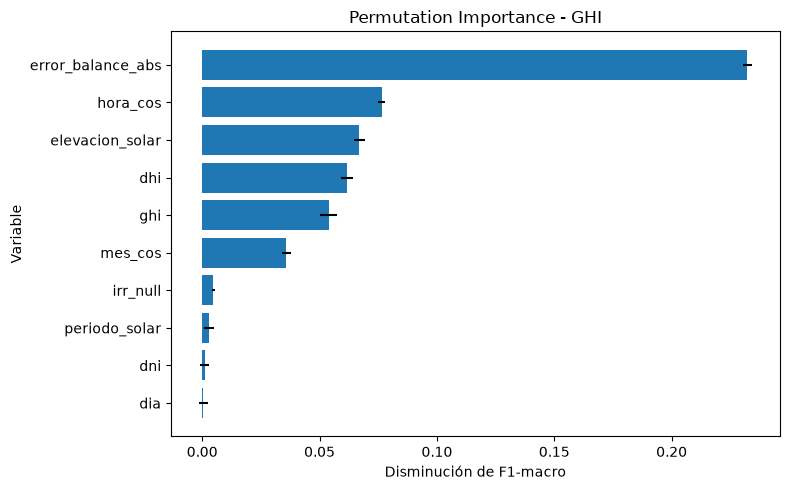

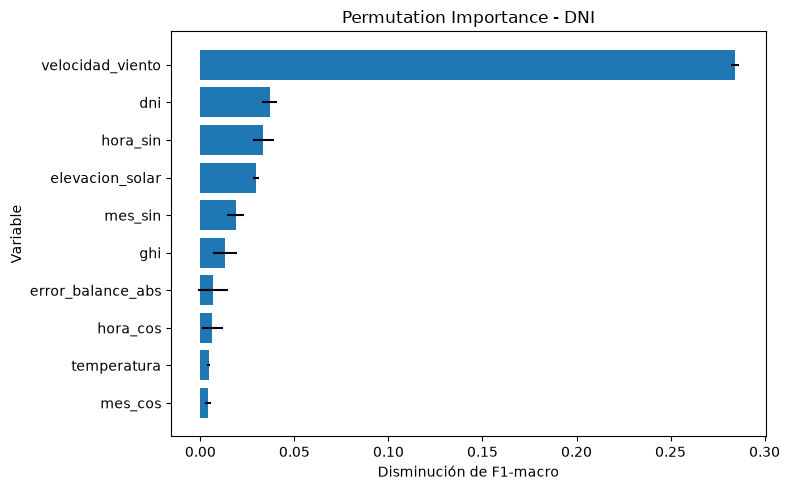

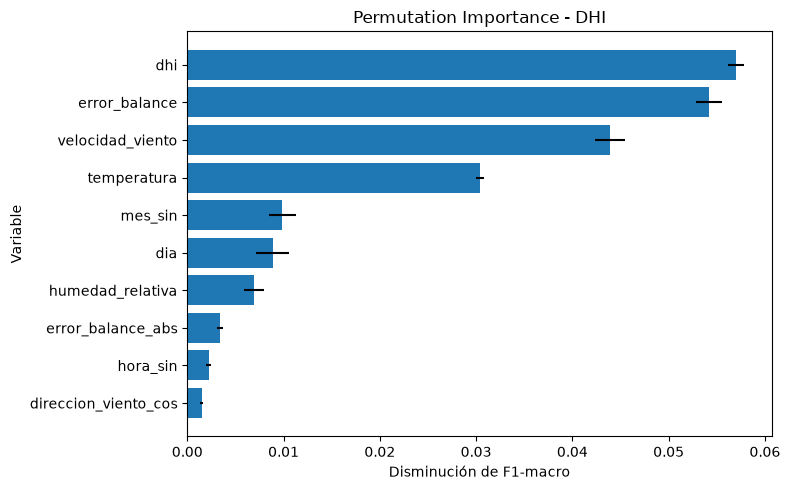

In [35]:
plot_permutation_importance(pi_ghi, "GHI")
plot_permutation_importance(pi_dni, "DNI")
plot_permutation_importance(pi_dhi, "DHI")

In [36]:
top_features = list(dict.fromkeys(
    pi_ghi.head(7)["feature"].tolist()
    + pi_dni.head(7)["feature"].tolist()
    + pi_dhi.head(7)["feature"].tolist()
))

pi_comparison = pd.DataFrame(index=top_features)

for target, result in {
    "GHI": pi_ghi,
    "DNI": pi_dni,
    "DHI": pi_dhi,
}.items():
    pi_comparison[target] = (
        result
        .set_index("feature")["importance_mean"]
        .reindex(top_features)
    )

pi_comparison

,GHI,DNI,DHI
error_balance_abs,0.232286,0.006862,0.003364
hora_cos,0.076405,0.006234,-0.000010
elevacion_solar,0.066843,0.029359,-0.017532
dhi,0.061768,0.002435,0.057022
ghi,0.053845,0.012951,-0.010337
mes_cos,0.035792,0.003999,0.000060
irr_null,0.004716,NaN,NaN
velocidad_viento,NaN,0.284284,0.043919
dni,0.001185,0.036880,0.001463
hora_sin,-0.000328,0.033473,0.002252


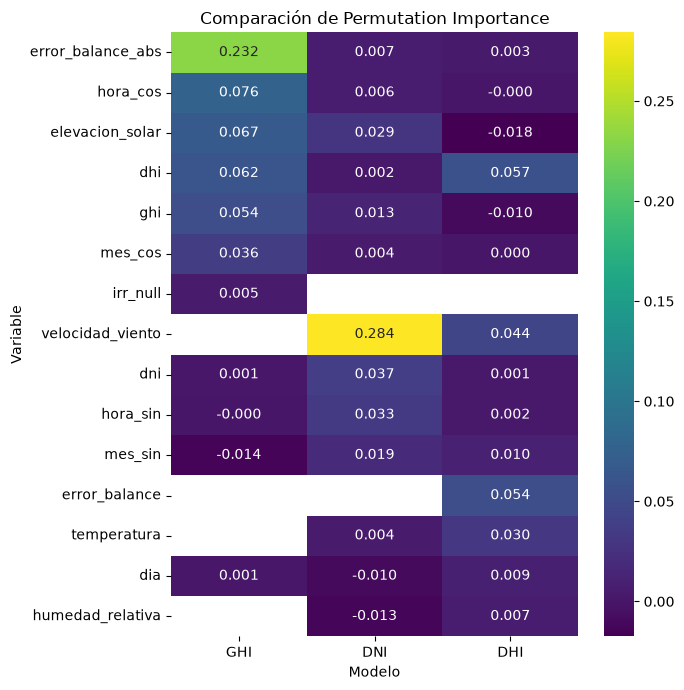

In [38]:
plt.figure(figsize=(7, 7))

sns.heatmap(
    pi_comparison,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    mask=pi_comparison.isna(),
)

plt.xlabel("Modelo")
plt.ylabel("Variable")
plt.title("Comparación de Permutation Importance")

plt.tight_layout()
plt.show()

### Resultados

Los resultados muestran que los tres modelos se apoyan en combinaciones de variables diferentes, lo que indica que la identificación de los códigos de calidad de GHI, DNI y DHI no responde exactamente a los mismos patrones.

En **GHI**, `error_balance_abs` presenta una importancia claramente superior al resto de variables. Esta característica representa la discrepancia absoluta en el balance entre las distintas componentes de irradiancia, por lo que su elevada relevancia resulta coherente con el objetivo del modelo: una pérdida de consistencia entre las componentes puede constituir una señal relevante sobre la calidad de una medición. Tras ella aparecen `hora_cos`, `elevacion_solar` y diferentes variables relacionadas con las propias componentes de irradiancia, mostrando que el modelo combina información sobre consistencia radiométrica con información temporal y solar.

En **DNI**, `velocidad_viento` presenta una importancia especialmente elevada respecto al resto de características. A continuación aparecen la propia `dni`, `hora_sin` y `elevacion_solar`. La elevada importancia de una variable meteorológica indica que el modelo ha encontrado una asociación predictiva relevante entre las condiciones atmosféricas y los códigos de calidad de DNI. Sin embargo, esta relación debe interpretarse únicamente desde un punto de vista predictivo: la importancia de una variable no implica que exista una relación causal entre ella y la aparición de mediciones incorrectas.

En **DHI**, la importancia aparece más distribuida entre distintas variables. Entre las principales se encuentran `dhi`, `error_balance`, `velocidad_viento` y `temperatura`. A diferencia de GHI y DNI, no existe una única característica con un dominio tan acusado, lo que sugiere que la clasificación de DHI depende de una combinación más equilibrada de información radiométrica, meteorológica y relacionada con el balance entre componentes.

La comparación conjunta muestra, por tanto, que existen algunas variables compartidas entre modelos, pero también características especialmente relevantes para cada target. Este comportamiento refuerza la decisión de analizar y modelizar GHI, DNI y DHI de forma independiente.

Estas importancias representan **dependencia predictiva** y no deben interpretarse directamente como relaciones causales. Además, su valor puede verse afectado cuando varias variables contienen información correlacionada o parcialmente redundante.

## 16.4. Interpretabilidad global mediante SHAP

Permutation Importance permite determinar qué variables son necesarias para mantener el rendimiento del modelo, pero no muestra directamente **cómo contribuyen dichas variables a las predicciones realizadas**. Para complementar esta información se utiliza **SHAP (SHapley Additive exPlanations)**.

SHAP asigna a cada variable una contribución para cada predicción. Un valor SHAP elevado en magnitud indica que esa característica ha tenido una influencia importante en la decisión del modelo para una observación concreta. Al agregar los valores absolutos de múltiples observaciones puede obtenerse una medida global de importancia.

El objetivo de este análisis es doble. En primer lugar, comprobar si las variables identificadas mediante Permutation Importance también aparecen como relevantes al estudiar directamente las decisiones del modelo. En segundo lugar, detectar posibles diferencias entre ambos métodos, ya que cada técnica analiza la importancia desde una perspectiva diferente.

Debido al mayor coste computacional de SHAP, el análisis se realiza sobre una muestra estratificada de 200 observaciones para cada modelo. De esta forma se garantiza la representación de los diferentes códigos de calidad sin necesidad de analizar el conjunto de evaluación completo. Para GHI se utiliza un explicador adaptado a la red neuronal, mientras que en DNI y DHI se emplean explicaciones sobre sus respectivos modelos finales.

In [84]:
def stratified_sample(X, y, n=200):
    sample_idx = (
        pd.DataFrame({"target": y}, index=X.index)
        .groupby("target", group_keys=False)
        .sample(
            n=max(1, n // y.nunique()),
            random_state=RANDOM_STATE,
        )
        .index
    )

    return X.loc[sample_idx]


X_shap_ghi = stratified_sample(
    X_test_ghi,
    y_test_ghi,
    n=200,
)

X_shap_dni = stratified_sample(
    X_test_dni,
    y_test_dni,
    n=200,
)

X_shap_dhi = stratified_sample(
    X_test_dhi,
    y_test_dhi,
    n=200,
)

In [85]:
def predict_proba_ghi(X):
    X = pd.DataFrame(
        X,
        columns=features_ghi,
    )

    X_scaled = scaler_ghi.transform(X)

    proba_1 = model_ghi.predict(
        X_scaled,
        verbose=0,
    ).ravel()

    return proba_1


def predict_proba_dni(X):
    X = pd.DataFrame(
        X,
        columns=features_dni,
    )

    return model_dni.predict_proba(X)


def predict_proba_dhi(X):
    X = pd.DataFrame(
        X,
        columns=features_dhi,
    )

    return model_dhi.predict_proba(X)

In [86]:
X_shap_ghi_scaled = scaler_ghi.transform(
    X_shap_ghi
)

background_ghi = X_shap_ghi_scaled[:30]

N_BACKGROUND = 100

background_dni = X_shap_dni.sample(
    n=N_BACKGROUND,
    random_state=RANDOM_STATE,
)

background_dhi = X_shap_dhi.sample(
    n=N_BACKGROUND,
    random_state=RANDOM_STATE,
)

In [87]:
explainer_ghi = shap.GradientExplainer(
    model_ghi,
    background_ghi,
)

explainer_dni = shap.Explainer(
    predict_proba_dni,
    background_dni,
)

explainer_dhi = shap.Explainer(
    predict_proba_dhi,
    background_dhi,
)

In [88]:
shap_values_ghi = explainer_ghi.shap_values(
    X_shap_ghi_scaled,
    nsamples=100,
    rseed=RANDOM_STATE,
)

shap_values_ghi = np.asarray(
    shap_values_ghi
)

if shap_values_ghi.ndim == 3:
    shap_values_ghi = shap_values_ghi[:, :, 0]

base_value_ghi = float(
    model_ghi.predict(
        background_ghi,
        verbose=0,
    ).mean()
)

shap_ghi = shap.Explanation(
    values=shap_values_ghi,
    base_values=np.full(
        len(X_shap_ghi),
        base_value_ghi,
    ),
    data=X_shap_ghi.to_numpy(),
    feature_names=features_ghi,
)

shap_dni = explainer_dni(X_shap_dni)
shap_dhi = explainer_dhi(X_shap_dhi)

c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 14))']
  warnings.warn(msg)
c:\Users\zacar\Desktop\Master IEBS DS Big Data\TFM_IEBS\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 14))']
  warnings.warn(msg)
PermutationExplainer explainer: 199it [00:26,  4.63it/s]                         
PermutationExplainer explainer: 199it [00:24,  4.74it/s]                         


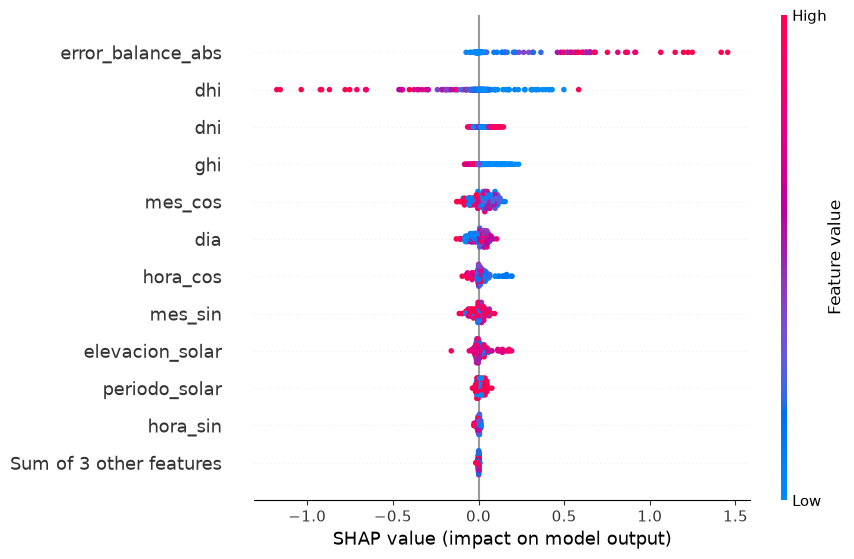

In [89]:
shap.plots.beeswarm(
    shap_ghi,
    max_display=12,
)

In [90]:
shap_importance_ghi = pd.DataFrame({
    "feature": features_ghi,
    "mean_abs_shap": np.abs(shap_ghi.values).mean(axis=0),
}).sort_values(
    "mean_abs_shap",
    ascending=False,
)

display(shap_importance_ghi.head(10))

,feature,mean_abs_shap
1,mes_cos,0.053493
2,dia,0.037085
4,hora_cos,0.034470
0,mes_sin,0.028126
11,elevacion_solar,0.026813
12,periodo_solar,0.018030
3,hora_sin,0.006396
5,minuto,0.001928
9,irr_null,0.000000
13,var_meteo_imp,0.000000


In [91]:
def multiclass_shap_importance(
    shap_values,
    features,
):
    importance = np.abs(
        shap_values.values
    ).mean(axis=(0, 2))

    return (
        pd.DataFrame({
            "feature": features,
            "mean_abs_shap": importance,
        })
        .sort_values(
            "mean_abs_shap",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [92]:
shap_importance_dni = multiclass_shap_importance(
    shap_dni,
    features_dni,
)

shap_importance_dhi = multiclass_shap_importance(
    shap_dhi,
    features_dhi,
)

display(shap_importance_dni.head(10))
display(shap_importance_dhi.head(10))

,feature,mean_abs_shap
0,velocidad_viento,0.191178
1,mes_sin,0.045855
2,elevacion_solar,0.028326
3,dni,0.027609
4,hora_sin,0.024649
5,humedad_relativa,0.018288
6,error_balance_abs,0.013744
7,dia,0.011347
8,ghi,0.010139
9,minuto,0.010094


,feature,mean_abs_shap
0,temperatura,0.069088
1,error_balance_rel,0.064092
2,error_balance,0.050618
3,dhi,0.046448
4,dia,0.035582
5,velocidad_viento,0.028328
6,elevacion_solar,0.028265
7,dni,0.025046
8,mes_sin,0.021883
9,ghi_estimado,0.021520


In [93]:
def plot_shap_importance(
    importance,
    target,
    top_n=10,
):
    data = (
        importance
        .head(top_n)
        .sort_values("mean_abs_shap")
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        data["feature"],
        data["mean_abs_shap"],
    )

    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Variable")
    plt.title(f"SHAP global - {target}")

    plt.tight_layout()
    plt.show()

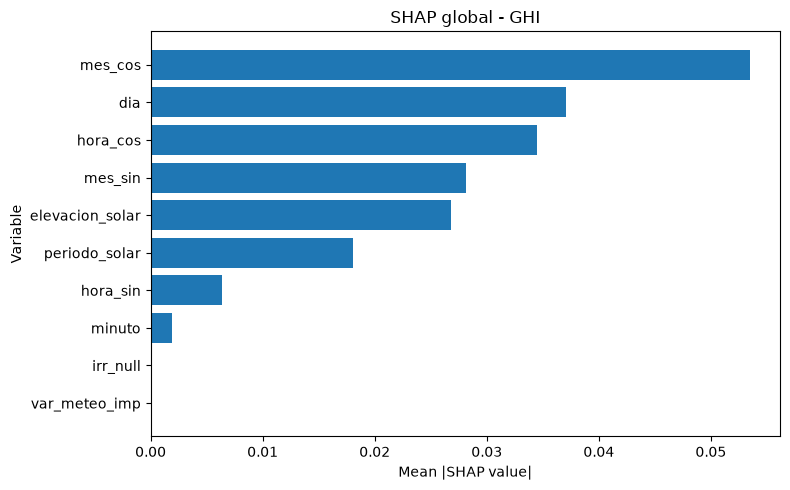

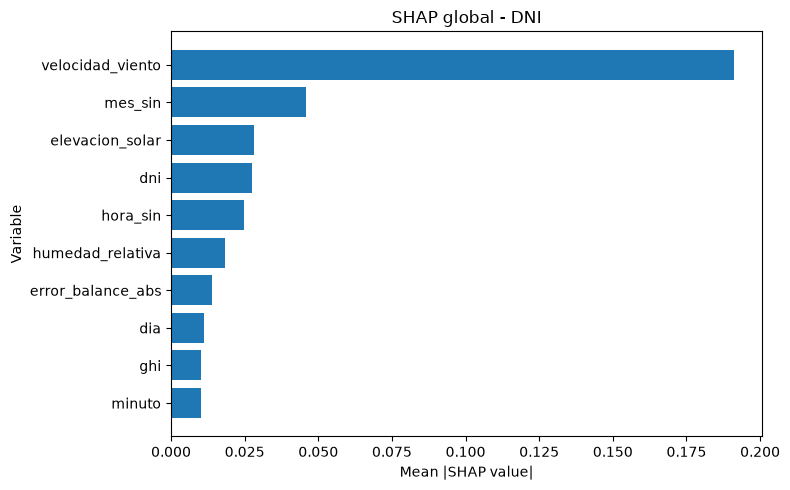

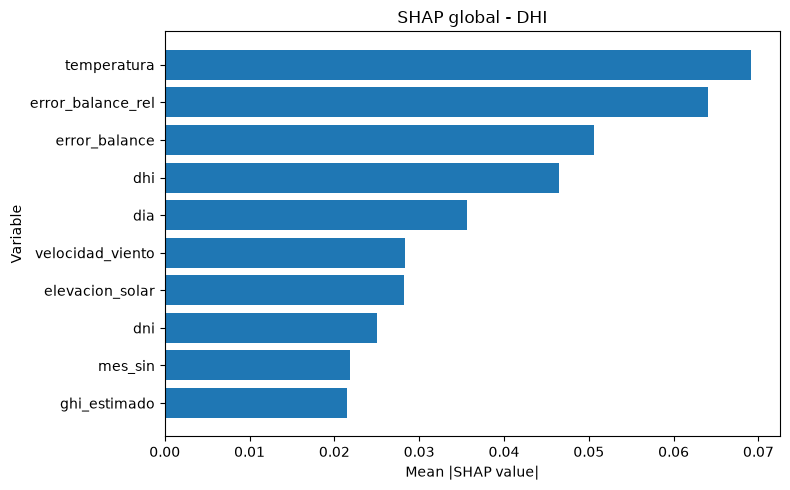

In [94]:
plot_shap_importance(
    shap_importance_ghi,
    "GHI",
)

plot_shap_importance(
    shap_importance_dni,
    "DNI",
)

plot_shap_importance(
    shap_importance_dhi,
    "DHI",
)

### Resultados

Los resultados obtenidos mediante SHAP confirman que los mecanismos de decisión son diferentes entre los tres modelos, aunque el grado de coincidencia con Permutation Importance varía según el target.

En **GHI**, SHAP asigna una influencia elevada principalmente a variables temporales y relacionadas con la posición solar. Entre las características más relevantes aparecen `mes_cos`, `dia`, `hora_cos`, `mes_sin` y `elevacion_solar`. Esto indica que la red neuronal utiliza de forma relevante la estructura temporal, diaria y estacional de las observaciones para modificar sus predicciones.

Este resultado difiere parcialmente del obtenido mediante Permutation Importance, donde `error_balance_abs` era claramente dominante. La coincidencia entre las cinco variables principales de ambos métodos es del **40 %**. Esta diferencia no implica necesariamente una contradicción: Permutation Importance cuantifica cuánto empeora el rendimiento cuando se destruye la información de una variable, mientras que SHAP distribuye entre las distintas características su contribución a las predicciones individuales. Cuando existen variables relacionadas o parcialmente redundantes, ambos enfoques pueden asignar la relevancia de forma diferente.

En **DNI** se observa la mayor consistencia entre ambas técnicas. `velocidad_viento` vuelve a aparecer como una de las variables más influyentes y entre las primeras posiciones aparecen también `mes_sin`, `elevacion_solar`, `dni` y `hora_sin`. La coincidencia entre las cinco principales variables identificadas por SHAP y Permutation Importance alcanza el **100 %**, lo que indica que la interpretación del modelo DNI resulta especialmente estable frente al método utilizado.

En **DHI**, SHAP destaca principalmente `temperatura`, `error_balance_rel`, `error_balance` y la propia `dhi`. En este caso, la coincidencia Top-5 con Permutation Importance alcanza el **60 %**. Ambos métodos identifican información meteorológica, radiométrica y relacionada con el balance como relevante, aunque difieren en la importancia concreta asignada a algunas características.

Por tanto, el análisis conjunto muestra tres grados diferentes de consistencia: elevada en DNI, intermedia en DHI y menor en GHI. Esta comparación resulta útil porque evita basar la interpretación de modelos complejos en una única técnica y permite obtener una visión más completa de la información utilizada durante las predicciones.

## 16.5. Interpretabilidad local

Los análisis anteriores describen el comportamiento agregado de los modelos, pero no permiten conocer exactamente **por qué se ha producido una predicción concreta**. Por este motivo, la interpretabilidad global se complementa con un análisis SHAP local.

Para cada target se seleccionan dos situaciones representativas: una predicción correcta realizada con elevada confianza y una predicción incorrecta realizada también con elevada confianza.

Los gráficos *waterfall* permiten observar cómo las distintas variables desplazan la salida del modelo desde un valor de referencia hasta la predicción finalmente obtenida. De esta forma puede identificarse qué características favorecen o contrarrestan una decisión concreta.

El interés principal se encuentra en los errores de elevada confianza. Estos casos permiten estudiar situaciones en las que el modelo no solo se equivoca, sino que además toma la decisión con una seguridad aparentemente alta, lo que resulta especialmente relevante de cara a una posible aplicación práctica del sistema.

In [95]:
pred_ghi_shap = predict_ghi(X_shap_ghi)
pred_dni_shap = predict_dni(X_shap_dni)
pred_dhi_shap = predict_dhi(X_shap_dhi)

proba_ghi_shap = predict_proba_ghi(X_shap_ghi)
proba_dni_shap = predict_proba_dni(X_shap_dni)
proba_dhi_shap = predict_proba_dhi(X_shap_dhi)

y_shap_ghi = y_test_ghi.loc[X_shap_ghi.index].to_numpy()
y_shap_dni = y_test_dni.loc[X_shap_dni.index].to_numpy()
y_shap_dhi = y_test_dhi.loc[X_shap_dhi.index].to_numpy()

In [96]:
confidence_ghi = np.maximum(
    proba_ghi_shap,
    1 - proba_ghi_shap,
)

confidence_dni = proba_dni_shap.max(axis=1)
confidence_dhi = proba_dhi_shap.max(axis=1)

In [97]:
def select_local_cases(
    y_true,
    y_pred,
    confidence,
):
    correct = np.where(y_true == y_pred)[0]
    errors = np.where(y_true != y_pred)[0]

    correct_idx = correct[
        np.argmax(confidence[correct])
    ]

    error_idx = (
        errors[np.argmax(confidence[errors])]
        if len(errors) > 0
        else None
    )

    return correct_idx, error_idx

In [98]:
cases_ghi = select_local_cases(
    y_shap_ghi,
    pred_ghi_shap,
    confidence_ghi,
)

cases_dni = select_local_cases(
    y_shap_dni,
    pred_dni_shap,
    confidence_dni,
)

cases_dhi = select_local_cases(
    y_shap_dhi,
    pred_dhi_shap,
    confidence_dhi,
)

print("GHI:", cases_ghi)
print("DNI:", cases_dni)
print("DHI:", cases_dhi)

GHI: (np.int64(111), np.int64(126))
DNI: (np.int64(141), np.int64(108))
DHI: (np.int64(143), np.int64(1))


In [99]:
def show_case_info(
    target,
    cases,
    y_true,
    y_pred,
    confidence,
):
    for name, idx in zip(
        ["Correcta", "Error"],
        cases,
    ):
        if idx is None:
            continue

        print(
            f"{target} | {name} | "
            f"Real: {y_true[idx]} | "
            f"Predicción: {y_pred[idx]} | "
            f"Confianza: {confidence[idx]:.3f}"
        )

In [100]:
show_case_info(
    "GHI",
    cases_ghi,
    y_shap_ghi,
    pred_ghi_shap,
    confidence_ghi,
)

show_case_info(
    "DNI",
    cases_dni,
    y_shap_dni,
    pred_dni_shap,
    confidence_dni,
)

show_case_info(
    "DHI",
    cases_dhi,
    y_shap_dhi,
    pred_dhi_shap,
    confidence_dhi,
)

GHI | Correcta | Real: 1 | Predicción: 1 | Confianza: 1.000
GHI | Error | Real: 1 | Predicción: 0 | Confianza: 0.934
DNI | Correcta | Real: 2 | Predicción: 2 | Confianza: 1.000
DNI | Error | Real: 1 | Predicción: 0 | Confianza: 0.968
DHI | Correcta | Real: 2 | Predicción: 2 | Confianza: 1.000
DHI | Error | Real: 0 | Predicción: 2 | Confianza: 1.000


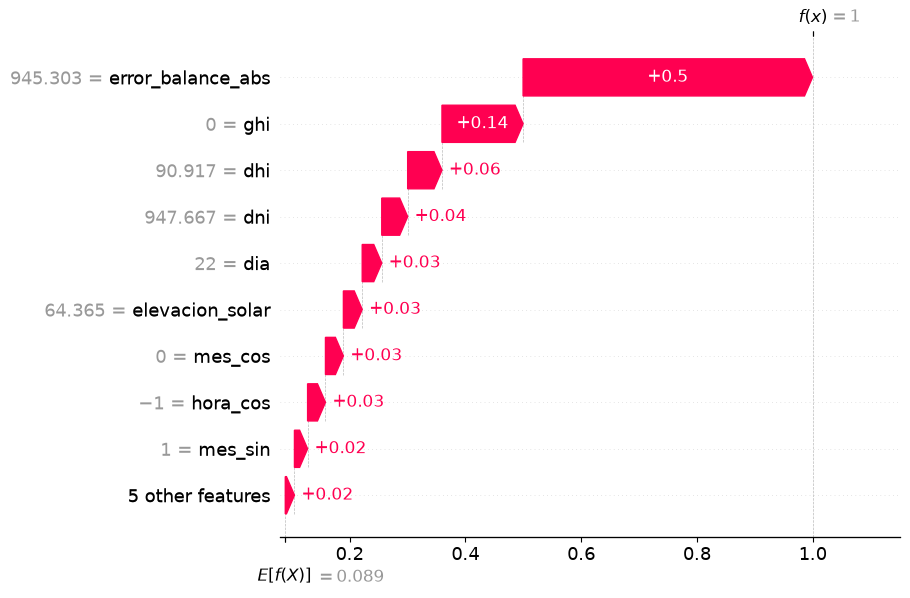

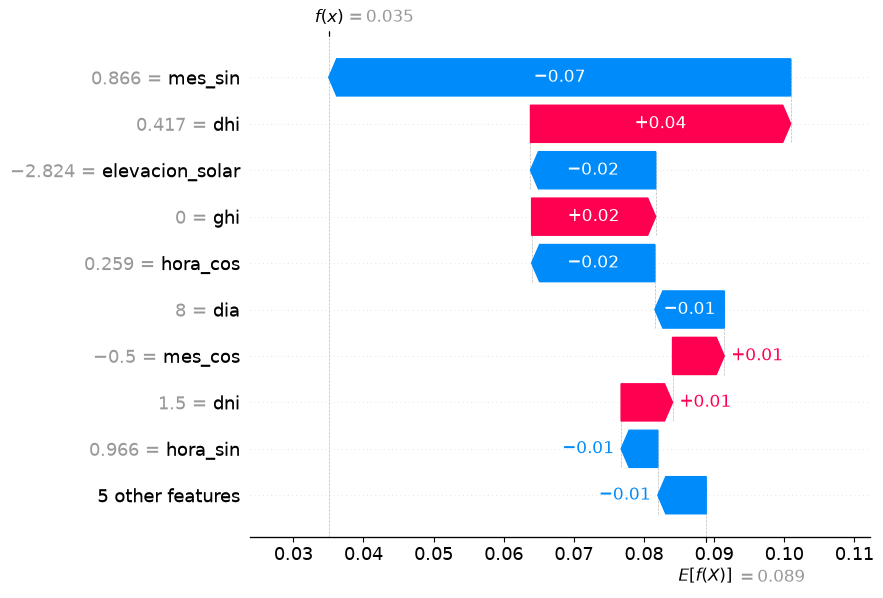

In [101]:
for idx in cases_ghi:
    if idx is not None:
        shap.plots.waterfall(
            shap_ghi[idx],
            max_display=10,
        )

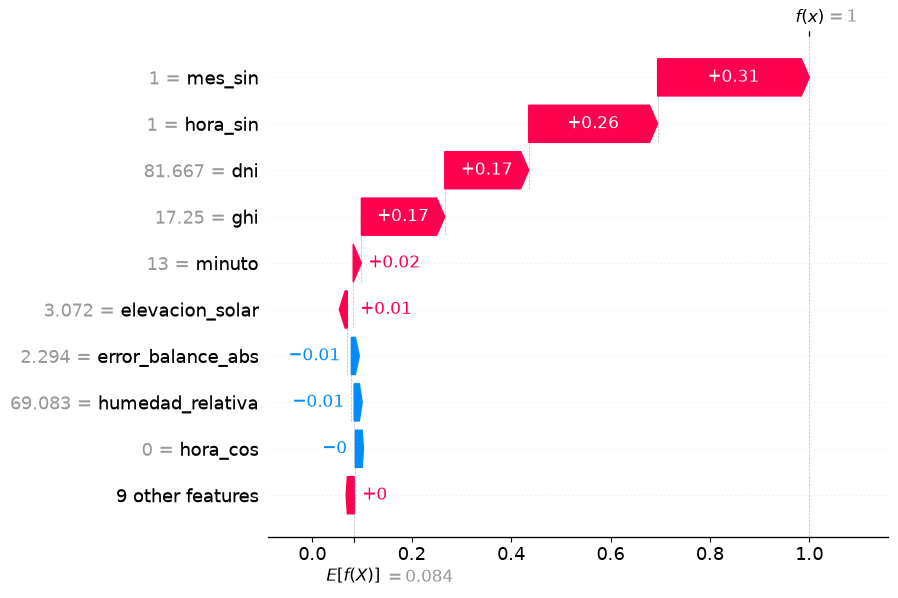

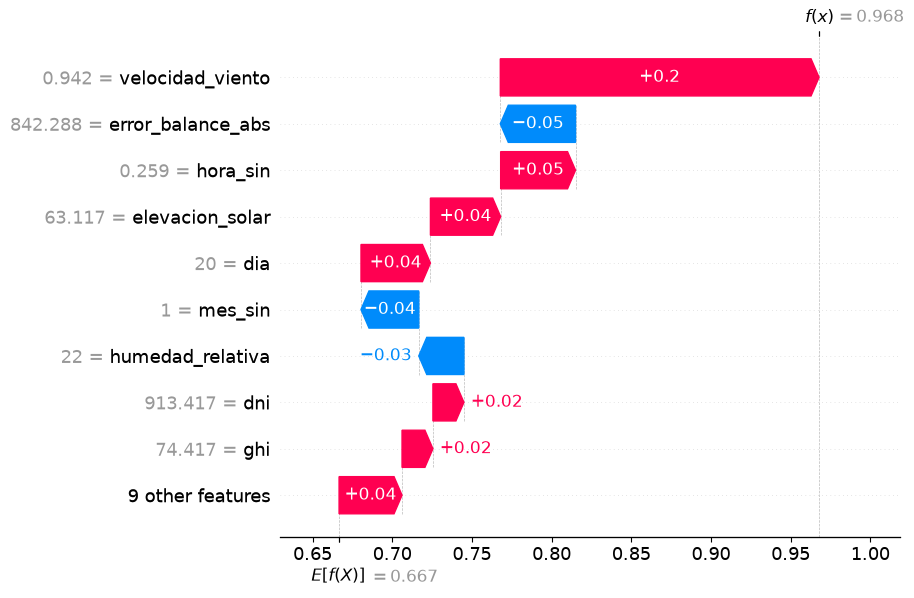

In [102]:
for idx in cases_dni:
    if idx is not None:
        predicted_class = int(pred_dni_shap[idx])

        shap.plots.waterfall(
            shap_dni[idx, :, predicted_class],
            max_display=10,
        )

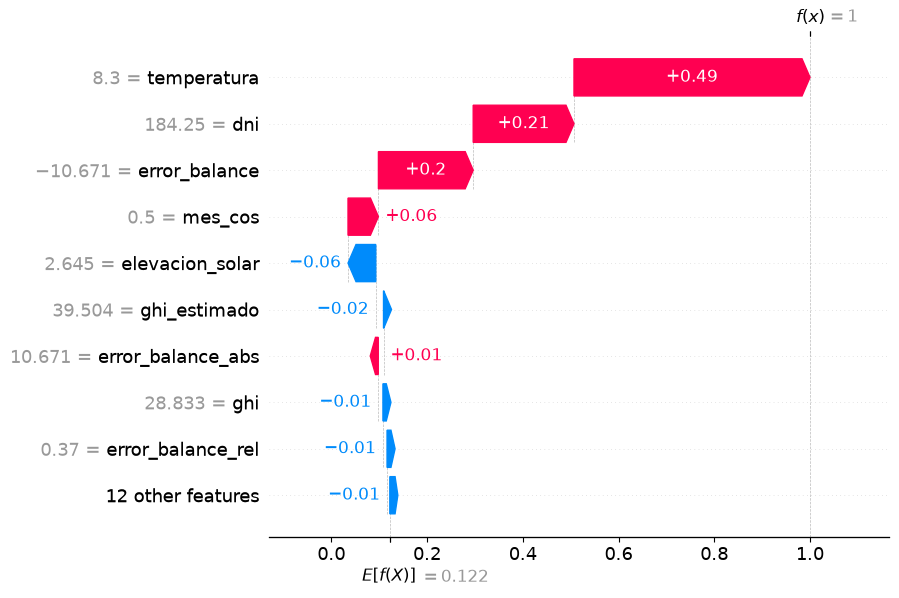

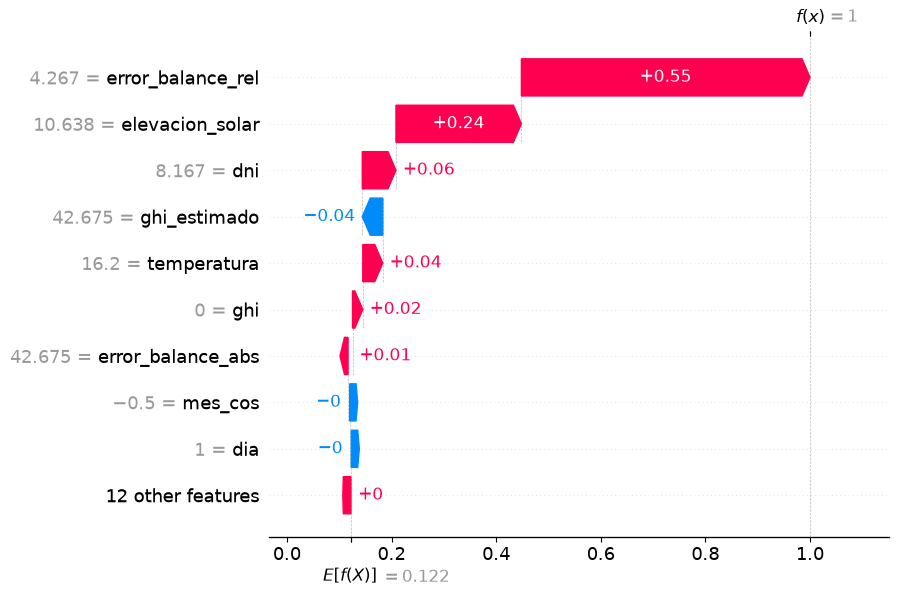

In [103]:
for idx in cases_dhi:
    if idx is not None:
        predicted_class = int(pred_dhi_shap[idx])

        shap.plots.waterfall(
            shap_dhi[idx, :, predicted_class],
            max_display=10,
        )

### Resultados

Las explicaciones locales muestran que una confianza elevada no garantiza necesariamente que una clasificación sea correcta.

En **GHI**, el error seleccionado presenta una confianza aproximada del **93,4 %**, mientras que en **DNI** alcanza aproximadamente el **96,8 %**. En **DHI** aparece incluso un caso incorrecto realizado con una confianza prácticamente máxima.

Los gráficos *waterfall* permiten comprobar que estas decisiones no suelen estar provocadas por una única característica aislada. Por el contrario, son el resultado de la combinación de distintas contribuciones que desplazan progresivamente la salida hacia la clase finalmente seleccionada por el modelo.

La principal aportación de SHAP local es, por tanto, permitir estudiar casos individuales que las métricas agregadas no pueden explicar. Dos modelos pueden presentar un buen rendimiento global y, aun así, cometer errores concretos derivados de determinadas combinaciones de variables.

Estos resultados no deben interpretarse como una evaluación formal de la calibración de probabilidades, ya que únicamente se han seleccionado algunos casos representativos. Sí muestran, sin embargo, que pueden existir observaciones en las que los modelos realizan predicciones incorrectas con elevada seguridad.

Desde una perspectiva de aplicación real, disponer de este nivel de explicabilidad permitiría analizar predicciones especialmente relevantes o inesperadas y conocer qué información ha impulsado la decisión, en lugar de utilizar los modelos como sistemas completamente opacos.

## 16.6. Análisis de errores

La interpretabilidad permite conocer qué información utilizan los modelos, pero todavía queda una cuestión fundamental: **en qué situaciones concretas presentan mayores dificultades**.

Para responder a esta pregunta se analizan los errores sobre el conjunto completo de evaluación. En lugar de volver a calcular las métricas globales ya estudiadas anteriormente, se segmentan las predicciones correctas e incorrectas según diferentes condiciones presentes en los datos.

Se estudian dos tipos principales de factores:

- **Condiciones solares y temporales**, mediante el periodo solar, la elevación del Sol y la hora del día.
- **Calidad y tratamiento de los datos**, mediante los indicadores `irr_null` y `var_meteo_imp`.

El objetivo no es únicamente identificar cuánto falla cada modelo, sino **caracterizar las condiciones en las que esos errores son más frecuentes**. Esta información permite detectar regiones especialmente problemáticas y conocer mejor las limitaciones de los modelos finales.

In [104]:
error_analysis = df_test[
    [
        "fecha",
        "periodo_solar",
        "elevacion_solar",
        "irr_null",
        "var_meteo_imp",
    ]
].copy()

error_analysis["pred_ghi"] = predict_ghi(X_test_ghi)
error_analysis["pred_dni"] = predict_dni(X_test_dni)
error_analysis["pred_dhi"] = predict_dhi(X_test_dhi)

error_analysis["error_ghi"] = (
    error_analysis["pred_ghi"].to_numpy()
    != y_test_ghi.to_numpy()
)

error_analysis["error_dni"] = (
    error_analysis["pred_dni"].to_numpy()
    != y_test_dni.to_numpy()
)

error_analysis["error_dhi"] = (
    error_analysis["pred_dhi"].to_numpy()
    != y_test_dhi.to_numpy()
)

error_analysis["hora"] = error_analysis["fecha"].dt.hour
error_analysis["mes"] = error_analysis["fecha"].dt.month

In [105]:
errors_by_period = (
    error_analysis
    .groupby("periodo_solar")[
        ["error_ghi", "error_dni", "error_dhi"]
    ]
    .mean()
    .mul(100)
)

display(errors_by_period.round(2))

,error_ghi,error_dni,error_dhi
periodo_solar,,,
dia,7.56,1.69,21.54
noche,7.30,1.29,4.49


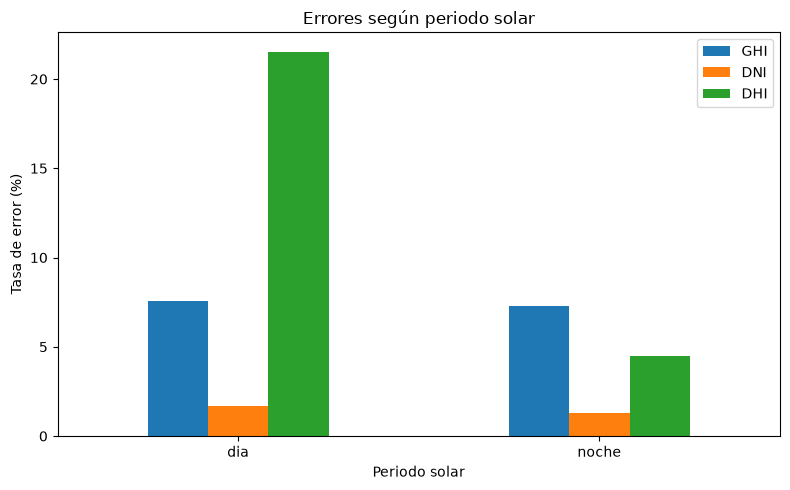

In [106]:
errors_by_period.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.ylabel("Tasa de error (%)")
plt.xlabel("Periodo solar")
plt.title("Errores según periodo solar")
plt.xticks(rotation=0)
plt.legend(["GHI", "DNI", "DHI"])

plt.tight_layout()
plt.show()

In [107]:
day_errors = error_analysis[
    error_analysis["periodo_solar"] == "dia"
].copy()

day_errors["elevation_range"] = pd.cut(
    day_errors["elevacion_solar"],
    bins=[0, 5, 15, 30, 45, 60, 90],
    include_lowest=True,
)

errors_by_elevation = (
    day_errors
    .groupby(
        "elevation_range",
        observed=True,
    )[["error_ghi", "error_dni", "error_dhi"]]
    .mean()
    .mul(100)
)

display(errors_by_elevation.round(2))

,error_ghi,error_dni,error_dhi
elevation_range,,,
"(-0.001, 5.0]",19.73,6.91,15.79
"(5.0, 15.0]",11.68,1.96,20.84
"(15.0, 30.0]",5.85,0.88,15.69
"(30.0, 45.0]",4.37,0.73,16.90
"(45.0, 60.0]",4.73,1.27,26.26
"(60.0, 90.0]",7.57,2.00,44.58


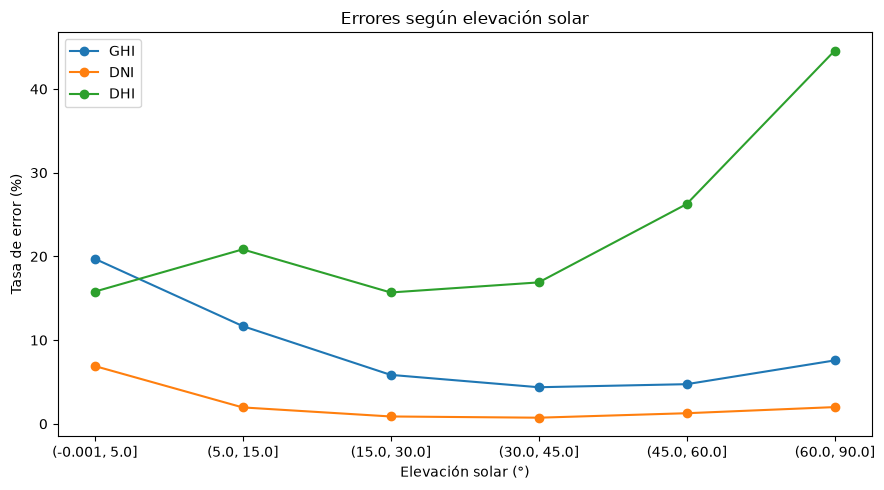

In [108]:
errors_by_elevation.plot(
    marker="o",
    figsize=(9, 5),
)

plt.ylabel("Tasa de error (%)")
plt.xlabel("Elevación solar (°)")
plt.title("Errores según elevación solar")
plt.legend(["GHI", "DNI", "DHI"])

plt.tight_layout()
plt.show()

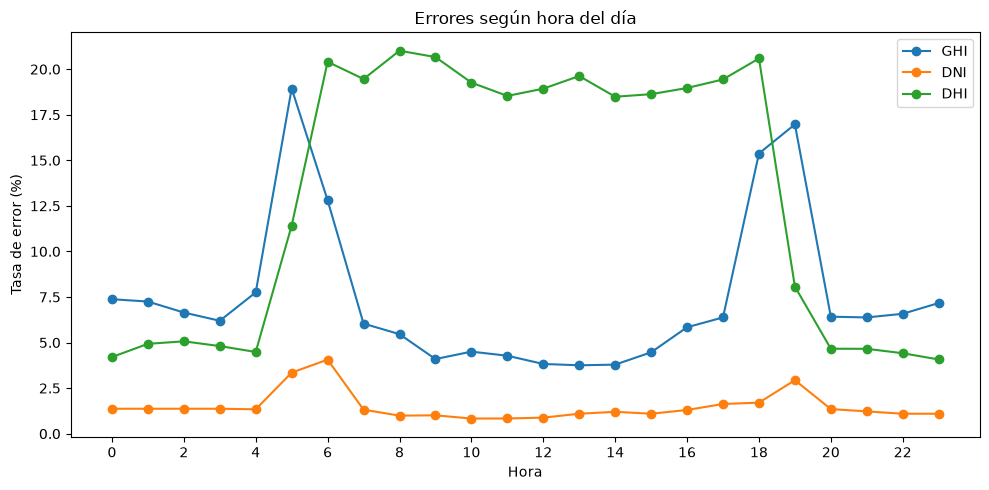

In [109]:
errors_by_hour = (
    error_analysis
    .groupby("hora")[
        ["error_ghi", "error_dni", "error_dhi"]
    ]
    .mean()
    .mul(100)
)

errors_by_hour.plot(
    marker="o",
    figsize=(10, 5),
)

plt.ylabel("Tasa de error (%)")
plt.xlabel("Hora")
plt.title("Errores según hora del día")
plt.xticks(range(0, 24, 2))
plt.legend(["GHI", "DNI", "DHI"])

plt.tight_layout()
plt.show()

### 16.6.1. Condiciones solares y temporales

Los resultados muestran que la distribución de los errores depende considerablemente de la componente de irradiancia estudiada.

En **GHI**, la tasa general de error es relativamente similar entre los periodos de día y noche, por lo que esta división por sí sola no permite identificar claramente el origen de las principales dificultades. Sin embargo, al considerar la elevación solar aparece un patrón mucho más definido. El intervalo comprendido entre **0° y 5°** presenta una tasa de error próxima al **19,7 %**, claramente superior a la observada para elevaciones solares más altas. Además, la máxima tasa de error por hora aparece alrededor de las **05:00**.

Ambos resultados indican que las condiciones próximas a las transiciones entre noche y día constituyen una región especialmente compleja para el modelo GHI. Con elevaciones solares reducidas, las magnitudes de irradiancia se encuentran en fases de transición y pequeñas variaciones absolutas pueden representar cambios relativos importantes, aumentando la dificultad de clasificación. El análisis no demuestra que esta sea necesariamente la causa física del error, pero sí identifica una región operacional en la que el modelo presenta una menor robustez.

En **DNI**, el comportamiento general resulta más estable y las tasas de error son comparativamente menores. No obstante, vuelve a aparecer un incremento cuando el Sol se encuentra próximo al horizonte. Entre **0° y 5°** de elevación solar la tasa de error alcanza aproximadamente el **6,9 %**. La aparición de esta misma región problemática en GHI y DNI indica que las condiciones de baja elevación solar representan un escenario especialmente exigente para más de una de las componentes.

El comportamiento de **DHI** es claramente diferente. Durante el día, la tasa de error alcanza aproximadamente el **21,5 %**, frente a alrededor del **4,5 %** observado durante la noche. Además, en este caso la mayor dificultad no aparece cerca del horizonte, sino con elevaciones solares altas: entre **60° y 90°** la tasa de error alcanza aproximadamente el **44,6 %**.

Por tanto, no existe una única condición problemática común a los tres targets. GHI y DNI muestran mayores dificultades cuando el Sol se encuentra próximo al horizonte, mientras que DHI concentra una proporción elevada de sus fallos durante el día y con elevaciones solares altas.

Esta diferencia refuerza nuevamente la conveniencia de estudiar las tres componentes mediante modelos independientes, ya que cada una presenta mecanismos de error y regiones de dificultad diferentes.

In [110]:
errors_by_irr_null = (
    error_analysis
    .groupby("irr_null")[
        ["error_ghi", "error_dni", "error_dhi"]
    ]
    .agg(["mean", "count"])
)

display(errors_by_irr_null)

error_ghi         error_dni         error_dhi        
              mean   count      mean   count      mean   count
irr_null                                                      
False     0.071136  523813  0.014981  523813  0.131621  523813
True      1.000000    1787  0.000000    1787  0.000000    1787

In [111]:
errors_by_imputation = (
    error_analysis
    .groupby("var_meteo_imp")[
        ["error_ghi", "error_dni", "error_dhi"]
    ]
    .agg(["mean", "count"])
)

display(errors_by_imputation)

error_ghi         error_dni         error_dhi        
                   mean   count      mean   count      mean   count
var_meteo_imp                                                      
False          0.074282  525590  0.014915  525590  0.131161  525590
True           0.700000      10  0.800000      10  0.800000      10

### 16.6.2. Influencia de la calidad de los datos

Además de las condiciones solares y temporales, se analiza si los registros que han sufrido algún tipo de incidencia durante el preprocesamiento presentan un comportamiento diferente frente a los modelos.

El resultado más significativo aparece en **GHI**. Los **1.787 registros** identificados mediante `irr_null = True` son clasificados incorrectamente por este modelo, lo que supone una tasa de error del **100 %** dentro de este subconjunto.

Este resultado identifica una limitación muy concreta del modelo GHI: las observaciones en las que existe alguna componente de irradiancia ausente representan un escenario claramente más complejo que el comportamiento general del conjunto de evaluación. Por tanto, `irr_null` permite identificar previamente un tipo de observación para el que la clasificación automática de GHI presenta una fiabilidad especialmente reducida.

Desde una perspectiva práctica, estos registros podrían recibir un tratamiento específico en una futura implementación del sistema, por ejemplo mediante una regla adicional de control o mediante su envío a un proceso de revisión en lugar de utilizar únicamente la predicción automática.

En **DNI** y **DHI** no se observa el mismo deterioro asociado a `irr_null`, lo que vuelve a demostrar que los mecanismos de error dependen del target analizado.

Por otra parte, las observaciones que contienen variables meteorológicas imputadas (`var_meteo_imp`) presentan tasas de error elevadas en los tres modelos. Sin embargo, en el conjunto de evaluación únicamente existen **10 registros** con esta característica.

Este tamaño muestral es demasiado reducido para concluir que la imputación meteorológica provoca sistemáticamente un deterioro del rendimiento. Por tanto, estos porcentajes deben interpretarse únicamente como una señal indicativa y no como una conclusión generalizable.

El análisis permite así diferenciar entre una limitación respaldada por un número significativo de observaciones —la presencia de irradiancia ausente en GHI— y otra situación para la que todavía no existe evidencia suficiente —las variables meteorológicas imputadas—.

## 16.7. Síntesis de interpretabilidad y errores

Los análisis anteriores responden a preguntas diferentes pero complementarias sobre el comportamiento de los modelos finales:

- **Permutation Importance** permite conocer qué variables son necesarias para mantener el rendimiento predictivo.
- **SHAP global** estudia cómo se distribuye la contribución de las distintas variables entre las predicciones.
- **SHAP local** permite explicar por qué se ha producido una decisión individual.
- **El análisis de errores** identifica las condiciones bajo las cuales los modelos presentan mayores dificultades.

Para integrar estas perspectivas se compara la coincidencia entre los rankings obtenidos mediante Permutation Importance y SHAP y se resumen las principales condiciones asociadas a los errores de cada componente.

El objetivo es obtener una visión conjunta que permita responder no solo a **qué variables utilizan los modelos**, sino también a **cómo las utilizan y bajo qué condiciones sus predicciones resultan menos fiables**.

In [112]:
def top_feature_overlap(pi_result, shap_result, top_n=5):

    pi_features = set(
        pi_result.head(top_n)["feature"]
    )

    shap_features = set(
        shap_result.head(top_n)["feature"]
    )

    common = pi_features & shap_features

    return {
        "common_features": sorted(common),
        "n_common": len(common),
        "overlap": len(common) / top_n,
    }

In [113]:
importance_overlap = {
    "GHI": top_feature_overlap(
        pi_ghi,
        shap_importance_ghi,
    ),
    "DNI": top_feature_overlap(
        pi_dni,
        shap_importance_dni,
    ),
    "DHI": top_feature_overlap(
        pi_dhi,
        shap_importance_dhi,
    ),
}

pd.DataFrame(importance_overlap).T

,common_features,n_common,overlap
GHI,"[elevacion_solar, hora_cos]",2,0.4
DNI,"[dni, elevacion_solar, hora_sin, mes_sin, velo...",5,1.0
DHI,"[dhi, error_balance, temperatura]",3,0.6


In [114]:
worst_period = pd.DataFrame({
    target: {
        "periodo": errors_by_period[
            f"error_{target.lower()}"
        ].idxmax(),
        "error_%": errors_by_period[
            f"error_{target.lower()}"
        ].max(),
    }
    for target in ["GHI", "DNI", "DHI"]
}).T

In [115]:
worst_elevation = pd.DataFrame({
    target: {
        "intervalo": errors_by_elevation[
            f"error_{target.lower()}"
        ].idxmax(),
        "error_%": errors_by_elevation[
            f"error_{target.lower()}"
        ].max(),
    }
    for target in ["GHI", "DNI", "DHI"]
}).T

In [116]:
worst_hour = pd.DataFrame({
    target: {
        "hora": errors_by_hour[
            f"error_{target.lower()}"
        ].idxmax(),
        "error_%": errors_by_hour[
            f"error_{target.lower()}"
        ].max(),
    }
    for target in ["GHI", "DNI", "DHI"]
}).T

In [117]:
final_summary = pd.DataFrame({
    "Target": ["GHI", "DNI", "DHI"],

    "Feature principal PI": [
        pi_ghi.iloc[0]["feature"],
        pi_dni.iloc[0]["feature"],
        pi_dhi.iloc[0]["feature"],
    ],

    "Feature principal SHAP": [
        shap_importance_ghi.iloc[0]["feature"],
        shap_importance_dni.iloc[0]["feature"],
        shap_importance_dhi.iloc[0]["feature"],
    ],

    "Coincidencia Top-5": [
        importance_overlap["GHI"]["overlap"],
        importance_overlap["DNI"]["overlap"],
        importance_overlap["DHI"]["overlap"],
    ],

    "Periodo con más error": [
        f"{worst_period.loc[t, 'periodo']} "
        f"({worst_period.loc[t, 'error_%']:.2f} %)"
        for t in ["GHI", "DNI", "DHI"]
    ],

    "Elevación con más error": [
        f"{worst_elevation.loc[t, 'intervalo']} "
        f"({worst_elevation.loc[t, 'error_%']:.2f} %)"
        for t in ["GHI", "DNI", "DHI"]
    ],

    "Hora con más error": [
        f"{int(worst_hour.loc[t, 'hora']):02d}:00 "
        f"({worst_hour.loc[t, 'error_%']:.2f} %)"
        for t in ["GHI", "DNI", "DHI"]
    ],
})

display(final_summary)

,Target,Feature principal PI,Feature principal SHAP,Coincidencia Top-5,Periodo con más error,Elevación con más error,Hora con más error
0,GHI,error_balance_abs,mes_cos,0.4,dia (7.56 %),"(-0.001, 5.0] (19.73 %)",05:00 (18.94 %)
1,DNI,velocidad_viento,velocidad_viento,1.0,dia (1.69 %),"(-0.001, 5.0] (6.91 %)",06:00 (4.06 %)
2,DHI,dhi,temperatura,0.6,dia (21.54 %),"(60.0, 90.0] (44.58 %)",08:00 (21.01 %)


### Resultados conjuntos

La síntesis muestra una consistencia diferente entre los métodos de interpretabilidad según el target.

En **DNI**, las cinco variables principales identificadas mediante Permutation Importance aparecen también entre las cinco principales de SHAP, alcanzando una coincidencia del **100 %**. Este resultado indica que la interpretación del modelo es especialmente estable frente a la metodología utilizada.

En **DHI**, la coincidencia alcanza el **60 %**, mostrando que ambos métodos comparten una parte importante de las variables consideradas relevantes, aunque también existen diferencias en la importancia relativa asignada a algunas características.

En **GHI**, la coincidencia Top-5 es del **40 %**, reflejando una mayor diferencia entre ambas perspectivas. Permutation Importance destaca especialmente la importancia del balance radiométrico para mantener el rendimiento, mientras que SHAP muestra una influencia relevante de variables temporales y solares en las predicciones individuales.

Las condiciones asociadas a los errores también presentan diferencias claras. GHI y DNI concentran sus mayores dificultades cuando la elevación solar se encuentra próxima al horizonte, mientras que DHI presenta su mayor degradación durante condiciones diurnas y con elevaciones solares elevadas.

Por tanto, la combinación de interpretabilidad y análisis de errores permite obtener una caracterización más completa que la proporcionada por cualquiera de los análisis de forma independiente.

## 16.8. Conclusiones

El análisis desarrollado complementa la evaluación predictiva de los modelos finales con una caracterización de sus mecanismos de decisión y de los principales escenarios en los que presentan dificultades.

Los resultados de interpretabilidad muestran que **GHI, DNI y DHI utilizan la información disponible de forma diferente**. En GHI destaca especialmente la información relacionada con el balance radiométrico desde el punto de vista de Permutation Importance, mientras que SHAP muestra también una influencia considerable de variables temporales y solares. En DNI existe una elevada consistencia entre ambos métodos, destacando especialmente `velocidad_viento` junto con variables solares, temporales y radiométricas. DHI presenta un comportamiento más distribuido entre características meteorológicas, radiométricas y relacionadas con el balance.

La comparación entre Permutation Importance y SHAP demuestra también que la importancia de una variable depende de la perspectiva desde la que se analiza el modelo. La coincidencia de las cinco principales variables alcanza el **40 % en GHI, el 100 % en DNI y el 60 % en DHI**, mostrando que ambas técnicas resultan complementarias especialmente en los modelos GHI y DHI.

Las explicaciones locales muestran además que pueden existir errores realizados con una confianza elevada. Aunque este análisis no constituye una evaluación formal de la calibración de probabilidades, permite comprobar que una elevada seguridad en la salida del modelo no garantiza necesariamente que la predicción sea correcta y demuestra el valor de disponer de mecanismos de explicabilidad para estudiar decisiones concretas.

El análisis de errores permite identificar además regiones específicas de menor fiabilidad. **GHI y DNI presentan mayores dificultades cuando la elevación solar se encuentra próxima al horizonte**, mientras que **DHI concentra una elevada proporción de errores durante el día y para elevaciones solares altas**.

De forma adicional, los registros con irradiancia ausente constituyen una limitación especialmente clara del modelo GHI: los **1.787 registros con `irr_null = True` presentan una tasa de error del 100 %**. Esta información permite identificar una situación concreta en la que una futura aplicación del sistema podría complementar la clasificación automática con reglas adicionales de control o revisión.

En conjunto, estos análisis permiten pasar de conocer únicamente **cuánto aciertan los modelos** a comprender también **qué información utilizan, cómo construyen determinadas decisiones y bajo qué condiciones presentan sus principales limitaciones**. Esta caracterización resulta especialmente relevante para valorar su posible utilización como sistema automatizado de apoyo al control de calidad de las mediciones de irradiancia.